# Phase 1 — C-MAPSS exploratory analysis

Issue [#10](https://github.com/vks-g/cmapss-rul-hybrid/issues/10). This notebook uses **training trajectories only** for descriptive analysis. FD001 is the primary subset; FD002–FD004 show how lifetime, sensors, and operating conditions differ. Raw files stay under `data/raw/CMAPSSData/` and are not committed.

This is exploration, not feature selection. Fit flat-sensor removal, scaling, and regime models inside each training fold only.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from rul.data.load import SENSOR_COLS, SUBSETS, load_subset

plt.style.use("seaborn-v0_8-whitegrid")
datasets = {name: load_subset(name) for name in SUBSETS}


## 1. Engines and lifetimes

Training engines run to failure, so each engine's maximum recorded cycle is its observed lifetime. Test trajectories stop early; their maximum cycle is **not** a lifetime.

In [2]:
lifetimes = {name: data.train.groupby("unit")["cycle"].max() for name, data in datasets.items()}
summary = pd.DataFrame.from_dict({
    name: {
        "train_engines": data.train["unit"].nunique(),
        "train_rows": len(data.train),
        "test_engines": data.test["unit"].nunique(),
        "test_rows": len(data.test),
        "train_life_min": lifetimes[name].min(),
        "train_life_median": lifetimes[name].median(),
        "train_life_max": lifetimes[name].max(),
    }
    for name, data in datasets.items()
}, orient="index")
summary.index.name = "subset"
display(summary)


,train_engines,train_rows,test_engines,test_rows,train_life_min,train_life_median,train_life_max
subset,,,,,,,
FD001,100,20631,100,13096,128,199.0,362
FD002,260,53759,259,33991,128,199.0,378
FD003,100,24720,100,16596,145,220.5,525
FD004,249,61249,248,41214,128,234.0,543


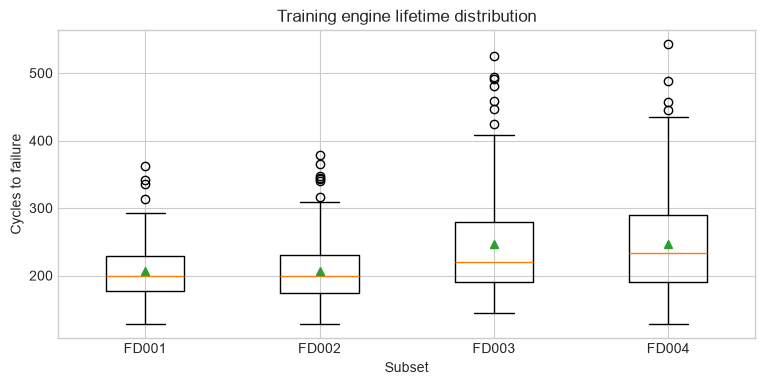

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot([lifetimes[name].to_numpy() for name in SUBSETS], tick_labels=SUBSETS, showmeans=True)
ax.set(title="Training engine lifetime distribution", ylabel="Cycles to failure", xlabel="Subset")
plt.show()


FD001 has 100 training engines and median lifetime 199 cycles. FD004 has 249 and median lifetime 234 cycles. The lifetime spread differs by subset; use engine-level splits when evaluating models.

## 2. Sensor distributions and trends

Compare representative sensors in FD001 and FD002. FD002 mixes six operating conditions, so a broad distribution can reflect conditions as well as degradation.

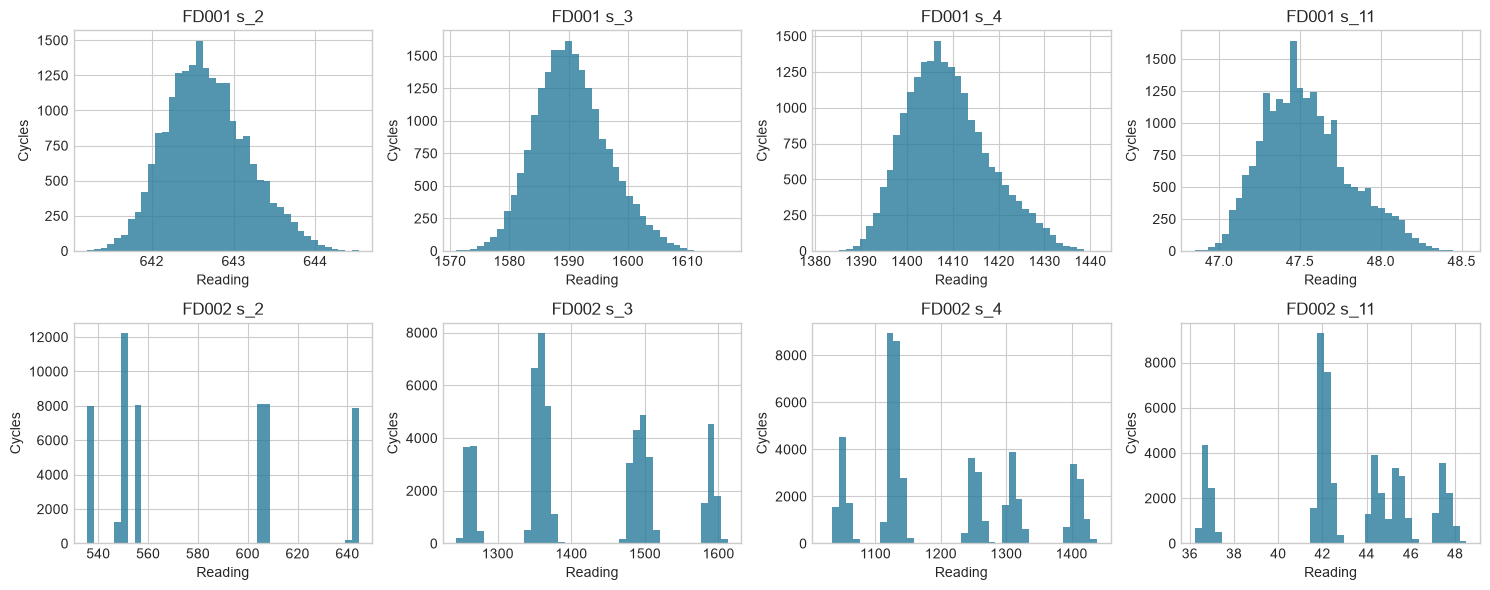

In [4]:
shown_sensors = ["s_2", "s_3", "s_4", "s_11"]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for row, name in enumerate(("FD001", "FD002")):
    train = datasets[name].train
    for col, sensor in enumerate(shown_sensors):
        axes[row, col].hist(train[sensor], bins=40, color="#287a9b", alpha=0.8)
        axes[row, col].set(title=f"{name} {sensor}", xlabel="Reading", ylabel="Cycles")
fig.tight_layout()
plt.show()


For a trajectory-level view, bin by fraction of each **training** engine's observed life. This uses the final cycle and must never become a model input at prediction time.

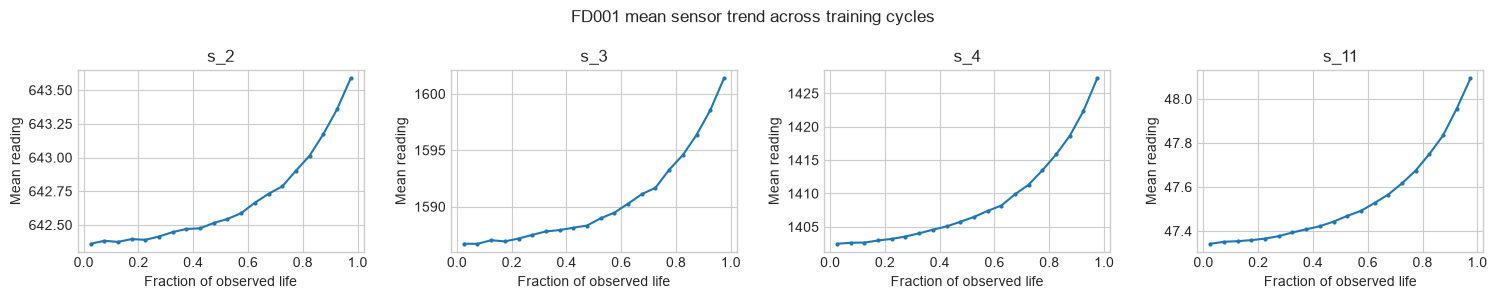

In [5]:
train = datasets["FD001"].train.copy()
train["life_fraction"] = train["cycle"] / train.groupby("unit")["cycle"].transform("max")
train["life_bin"] = pd.cut(train["life_fraction"], bins=np.linspace(0, 1, 21), include_lowest=True)
trends = train.groupby("life_bin", observed=True)[shown_sensors].mean()
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
for ax, sensor in zip(axes, shown_sensors):
    ax.plot(np.linspace(0.025, 0.975, len(trends)), trends[sensor], marker="o", markersize=2)
    ax.set(title=sensor, xlabel="Fraction of observed life", ylabel="Mean reading")
fig.suptitle("FD001 mean sensor trend across training cycles")
fig.tight_layout()
plt.show()


## 3. Constant and near-constant sensors

`n_unique == 1` means exactly constant. Here “near-constant” is an exploratory candidate with standard deviation under 0.01% of `max(abs(mean), 1)`; this scale-sensitive rule is **not** a production feature-selection threshold. Inspect per-regime and training-fold variability before removing sensors.

In [6]:
variability = []
for name, data in datasets.items():
    sensors = data.train[SENSOR_COLS]
    stats = pd.DataFrame({
        "subset": name,
        "sensor": SENSOR_COLS,
        "n_unique": sensors.nunique().to_numpy(),
        "mean": sensors.mean().to_numpy(),
        "std": sensors.std().to_numpy(),
    })
    stats["relative_std"] = stats["std"] / stats["mean"].abs().clip(lower=1)
    stats["status"] = np.select(
        [stats["n_unique"].eq(1), stats["relative_std"].lt(1e-4)],
        ["constant", "near-constant"], default="varying"
    )
    variability.append(stats)
variability = pd.concat(variability, ignore_index=True)
display(variability[variability["status"].ne("varying")].round(7).reset_index(drop=True))


,subset,sensor,n_unique,mean,std,relative_std,status
0,FD001,s_1,1,518.670000,0.000000,0.000000,constant
1,FD001,s_5,1,14.620000,0.000000,0.000000,constant
2,FD001,s_6,2,21.609803,0.001389,0.000064,near-constant
3,FD001,s_8,53,2388.096652,0.070986,0.000030,near-constant
4,FD001,s_10,1,1.300000,0.000000,0.000000,constant
5,FD001,s_13,56,2388.096152,0.071919,0.000030,near-constant
6,FD001,s_16,1,0.030000,0.000000,0.000000,constant
7,FD001,s_18,1,2388.000000,0.000000,0.000000,constant
8,FD001,s_19,1,100.000000,0.000000,0.000000,constant
9,FD003,s_1,1,518.670000,0.000000,0.000000,constant


FD001 has six exactly constant sensors: `s_1`, `s_5`, `s_10`, `s_16`, `s_18`, `s_19`; `s_6`, `s_8`, and `s_13` are near-constant candidates under the exploratory threshold. FD003 has five exactly constant sensors (`s_1`, `s_5`, `s_16`, `s_18`, `s_19`) and near-constant candidates `s_8` and `s_13`. FD002/FD004 have no exactly constant sensors across all operating conditions.

## 4. Sensor correlations

Pooled correlations describe the observed training data; FD002 correlations may partly reflect operating-regime shifts. Exact constants appear blank because their correlation is undefined.

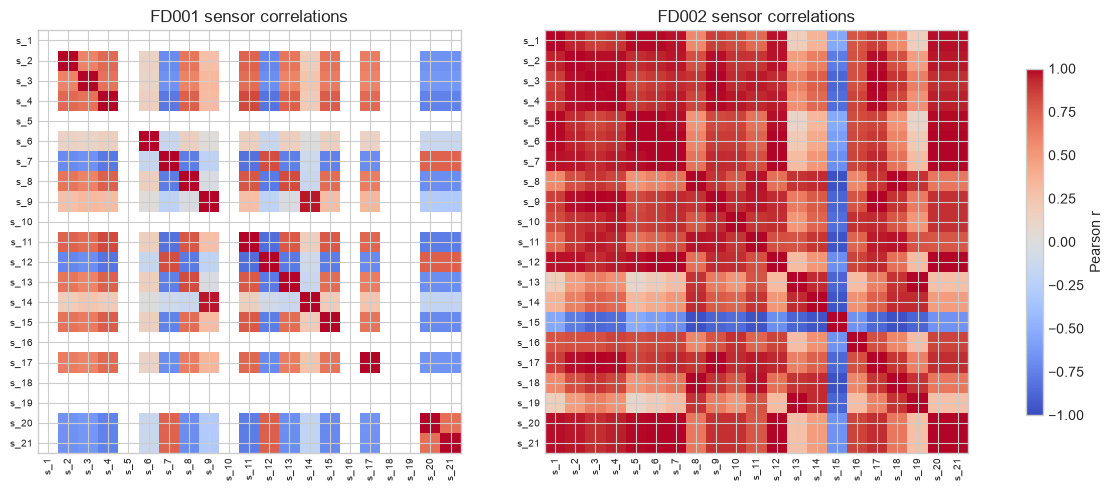

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, name in zip(axes, ("FD001", "FD002")):
    corr = datasets[name].train[SENSOR_COLS].corr()
    image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set(title=f"{name} sensor correlations", xticks=range(21), yticks=range(21),
           xticklabels=SENSOR_COLS, yticklabels=SENSOR_COLS)
    ax.tick_params(axis="x", labelrotation=90, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
fig.colorbar(image, ax=axes, shrink=0.75, label="Pearson r")
plt.show()


## 5. Operating settings in six-condition subsets

NASA's dataset readme specifies six operating conditions for FD002 and FD004. Rounded `op_1` separates six prominent bands; this is descriptive evidence, not a fitted regime detector (issue #13).

,FD002,FD004
rounded op_1,,
0.0,8044,9238
10.0,8096,9224
20.0,8122,9091
25.0,8002,9139
35.0,8037,9162
42.0,13458,15395


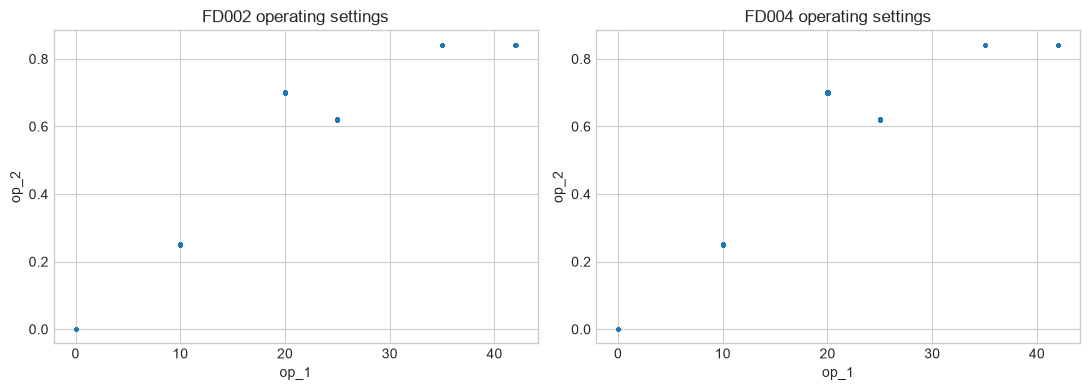

In [8]:
regime_counts = pd.DataFrame({
    name: datasets[name].train["op_1"].round().value_counts().sort_index()
    for name in ("FD002", "FD004")
}).fillna(0).astype(int)
regime_counts.index.name = "rounded op_1"
display(regime_counts)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, ("FD002", "FD004")):
    sample = datasets[name].train.sample(n=min(10_000, len(datasets[name].train)), random_state=42)
    ax.scatter(sample["op_1"], sample["op_2"], s=3, alpha=0.2)
    ax.set(title=f"{name} operating settings", xlabel="op_1", ylabel="op_2")
fig.tight_layout()
plt.show()


## 6. Degradation curves for sample engines

Raw `s_11` trajectories for three FD001 and three FD003 engines illustrate within-engine change and between-engine differences. Both subsets have one operating condition, so regime switching does not dominate these plots. These are examples, not population-average effects.

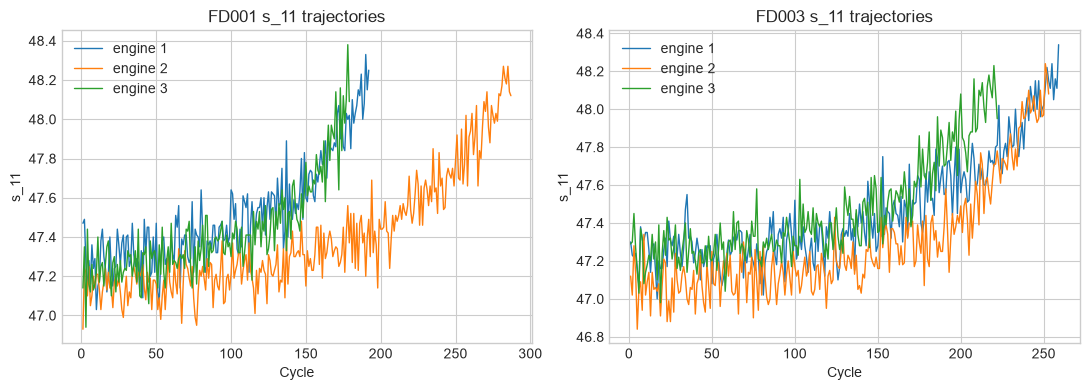

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, ("FD001", "FD003")):
    train = datasets[name].train
    for unit in (1, 2, 3):
        engine = train.loc[train["unit"].eq(unit)].sort_values("cycle")
        ax.plot(engine["cycle"], engine["s_11"], label=f"engine {unit}", linewidth=1)
    ax.set(title=f"{name} s_11 trajectories", xlabel="Cycle", ylabel="s_11")
    ax.legend()
fig.tight_layout()
plt.show()


### Handoff

Use these findings to motivate issue #11's sensor-cleaning choices and issue #12's Dataset & EDA report section. Recompute any selected sensors and transforms **within each training fold**; keep held-out engines untouched until evaluation.